In [29]:
import numpy as np
import math
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from ripser import ripser
from persim import plot_diagrams
def savepkl(obj, path):
    with open(path, 'wb') as f:
        pickle.dump(obj, f)

def loadpkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
import pyreadr 
import sys
import os
sys.path.append(os.path.abspath(".."))
from mpl_toolkits.mplot3d import Axes3D
from ripser import ripser
from persim import plot_diagrams
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import gridspec

def deco_pd(ax,diagrams,colors,markers,title,size=None,title_size=None,ticks=False,plot_only=None):
    # 1) plotting - origninal diagram
    plot_diagrams(diagrams,plot_only=plot_only, ax=ax, size=50)
    points = []
    for p in ax.collections:
        arr = p.get_offsets()
        for xy in arr:
            points.append(tuple(xy))
    x_max, y_max = max(points, key=lambda t: t[1])
    # 2) removing each points from the original diagram
    for artist in ax.collections[:]:
        artist.remove()
    # -------------------------------
    # no points in the diagram 
    # but diagonal line 
    # ------------------------------
    for i, diag in enumerate(diagrams):
        if type(diag)==int or len(diag) == 0:
            continue
        births = diag[:, 0]
        deaths = diag[:, 1]
    
        ax.scatter(
            births, deaths,
            s=size,
            marker=markers.get(i, "o"),
            color=colors.get(i, "black"),
            label=f"$H_{i}$"
        )
        if i==0:
            ax.scatter(x_max,y_max,s=size,marker=markers.get(i, "o"),
            color=colors.get(i, "black"))
    
    ax.set_title(title,fontsize=title_size)
    if title_size:
        ax.legend(fontsize=title_size-3,loc="lower right")
    else:
        ax.legend(fontsize=12,loc="lower right")
    if not ticks: 
        ax.set_xticks([])
        ax.set_yticks([])
        
def plot_persistence_intensity(
    PD_list,
    filename,
    title,
    title_size=16,
    grid_size=300,
    bandwidth=0.005,
    alpha=1.0,
    levels=100,
    cmap="viridis"
):
    """
    Estimate and visualize persistence intensity function.

    Parameters
    ----------
    PD_list : list of array, where each array is shape of (N, 2): Persistence diagram (birth, death).
    xlim, ylim : tuple, optional
        Plot ranges (min, max). If None, inferred from PD.
    grid_size : int
        Number of grid points per axis.
    bandwidth : float
        Gaussian kernel bandwidth.
    levels : int
        Number of contour levels.
    cmap : str
        Matplotlib colormap.

    Returns
    -------
    intensity : 2D ndarray
        Estimated intensity values.
    """
    colors = [
    '#ffffff',  
    '#253494'
            ]

    custom_cmap = LinearSegmentedColormap.from_list(
        'white_to_blue',
    colors,
    N=256
    )
    min_=np.inf
    max_=-np.inf
    for PD in PD_list: 
        min_= np.min([min_,PD[:, 0].min()])
        max_=np.max([max_,PD[:, 1].max()])

    xlim = (min_, max_)
    ylim = (min_, max_)

    grid_x = np.linspace(xlim[0], xlim[1], grid_size)
    grid_y = np.linspace(ylim[0], ylim[1], grid_size)
    X, Y = np.meshgrid(grid_x, grid_y, indexing="ij")
    
    # -------------------------
    # Intensity estimation
    # -------------------------
    intensity = np.zeros_like(X)
    for PD in PD_list:
        for k in range(PD.shape[0]):
            dx = X - PD[k, 0]
            dy = Y - PD[k, 1]
            intensity +=  np.exp(
                -(dx**2 + dy**2) / (2 * bandwidth**2)
            )
    intensity /= (len(PD_list) * np.sqrt(2 * np.pi * bandwidth**2)) 
    intensity[Y < X] = 0.0
    
    # -------------------------
    # Visualization
    # -------------------------
    fig = plt.figure(figsize=(16, 5))
    gs = gridspec.GridSpec(
    1, 4,
    width_ratios=[1, 1, 1, 1.4],  # intensity를 조금 더 넓게
    wspace=0.25
     )

    # -------------------------
    # Left: persistence diagrams
    # -------------------------
    markers = {0: "^", 1: "o"}
    colors  = {0: "#a1dab4", 1: "#225ea8"}
    axs_pd = [fig.add_subplot(gs[0, i]) for i in range(3)]
    
    for i, ax in enumerate(axs_pd):
        deco_pd(ax=ax,diagrams=[1,PD_list[i]],colors=colors,markers=markers,size=8,title_size=title_size,plot_only=[1],ticks=False,
                title=f'Persistence diagram {i+1}')
         
    # -------------------------
    # Right: intensity function
    # -------------------------
    ax_int = fig.add_subplot(gs[0, 3])

    plot_diagrams([1,PD_list[i]],plot_only=[1], ax=ax_int,legend=False)
    # removing each points from the original diagram
    for artist in ax_int.collections[:]:
        artist.remove()
        
    cf = ax_int.contourf(
    X, Y, intensity,
    levels=levels,
    cmap=custom_cmap
    )
    
    ax_int.set_title(title, fontsize=title_size)
    ax_int.set_xticks([])
    ax_int.set_yticks([])
    ax_int.set_box_aspect(1)

    
    cbar = fig.colorbar(cf, ax=ax_int, shrink=0.70)
    cbar.set_ticks([0])
    cbar.set_ticklabels(["0"])
    cbar.set_label("")
    cbar.ax.text(
    0.5, 1.02, "High",
    ha="center",
    va="bottom",
    transform=cbar.ax.transAxes,
    fontsize=title_size-1
    )
    
    # -------------------------
    # Save
    # -------------------------
    plt.tight_layout()
    plt.savefig(f"results/figures/figure_file/{filename}.png",bbox_inches="tight",pad_inches=0.02)
    plt.savefig(f"results/figures/figure_file/{filename}.pdf",bbox_inches="tight",pad_inches=0.02)
    plt.show()

## One circle versus Two circle

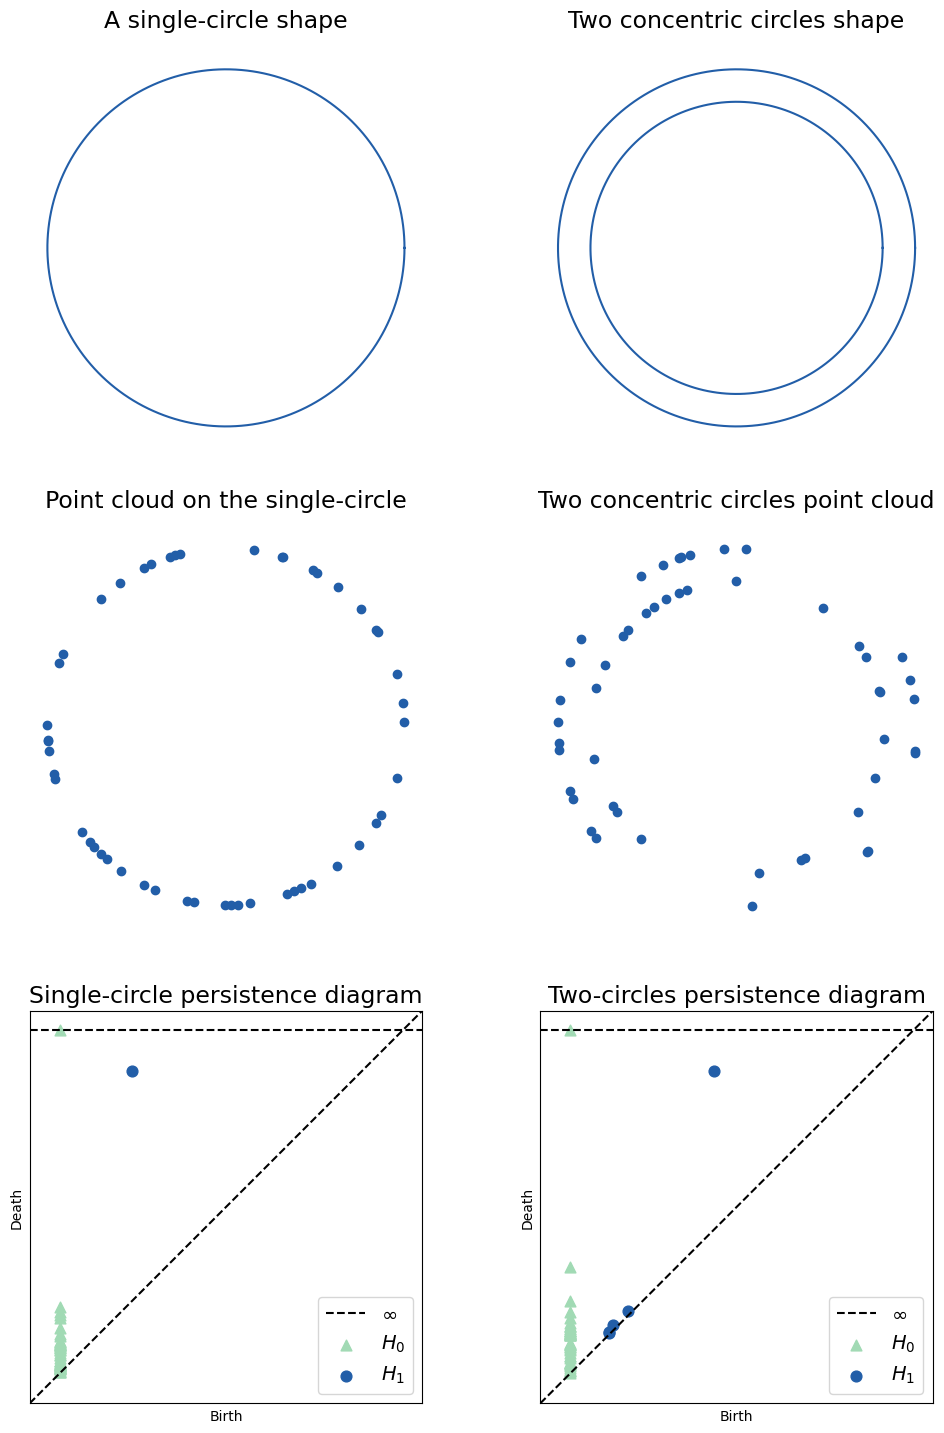

In [20]:
markers = {0: "^", 1: "o"}
colors  = {0: "#a1dab4", 1: "#225ea8"}

np.random.seed(10)
# --- 1. Sampling function ---
def sample_circle(radius, n_points):
    theta = np.random.uniform(0, 2*np.pi, n_points)
    x = radius * np.cos(theta)
    y = radius * np.sin(theta)
    return np.column_stack([x, y])

# --- 2. Generate data ---
n_points = 50

# one-circle: radius 1
one_circle_points = sample_circle(1.0, n_points)

# two-circle: radii 0.9 and 1.1
two_circle_points_inner = sample_circle(0.9, n_points//2)
two_circle_points_outer = sample_circle(1.1, n_points//2)
two_circle_points = np.vstack([two_circle_points_inner, two_circle_points_outer])

# --- 3. Compute Rips complex & Persistence diagrams ---
one_diagrams = ripser(one_circle_points)['dgms']
two_diagrams = ripser(two_circle_points)['dgms']

# --- 4. Visualization ---
fig, axes = plt.subplots(3, 2, figsize=(10, 15))

# ----- Row 1: one-circle -----
# plot the circle itself
theta = np.linspace(0, 2*np.pi, 200)
axes[0,0].plot(np.cos(theta), np.sin(theta),color=colors[1])
axes[0,0].set_title('A single-circle shape',fontsize=17,pad=15)
axes[0,0].axis('equal')
axes[0,0].set_xticks([])
axes[0,0].set_yticks([])
axes[0,0].set_frame_on(False)

# plot the sampled points
axes[1,0].scatter(one_circle_points[:,0], one_circle_points[:,1],color=colors[1])
axes[1,0].set_title('Point cloud on the single-circle',fontsize=17,pad=15)
axes[1,0].axis('equal')
axes[1,0].set_xticks([])
axes[1,0].set_yticks([])
axes[1,0].set_frame_on(False)
deco_pd(ax=axes[2,0],diagrams=one_diagrams,colors=colors,markers=markers,size=60,title='Single-circle persistence diagram',title_size=17)

# ----- Row 2: two-circle -----
# plot the circles themselves
axes[0,1].plot(0.9*np.cos(theta), 0.9*np.sin(theta),color=colors[1])
axes[0,1].plot(1.1*np.cos(theta), 1.1*np.sin(theta),color=colors[1])
axes[0,1].set_title('Two concentric circles shape',fontsize=17,pad=15)
axes[0,1].axis('equal')
axes[0,1].set_xticks([])
axes[0,1].set_yticks([])
axes[0,1].set_frame_on(False)

# plot the sampled points
axes[1,1].scatter(two_circle_points[:,0], two_circle_points[:,1],color=colors[1])
axes[1,1].set_title('Two concentric circles point cloud',fontsize=17,pad=15)
axes[1,1].axis('equal')
axes[1,1].set_xticks([])
axes[1,1].set_yticks([])
axes[1,1].set_frame_on(False)

# plot the persistence diagram
deco_pd(ax=axes[2,1],diagrams=two_diagrams,colors=colors,markers=markers,size=60,title='Two-circles persistence diagram',title_size=17)
plt.tight_layout(pad=3.0)
plt.subplots_adjust(wspace=0.3)
plt.savefig("figures/figure_file/pointclouds_persistence.png", dpi=300)
plt.savefig("figures/figure_file/pointclouds_persistence.pdf")
plt.show() 



## Circles data  Empirical power

In [179]:
def simulation_to_latex_table(
    noise_levels,
    Aggtest_result, PI_result, PD_result, PL_result,
    weight_dictionary,
    caption1="Test comparison", caption2="Weight comparison",
    label1="tab:test_comp", label2="tab:weight_comp"
):
    # Helper for formatting values (0.001 → <0.001)
    def fmt(x):
        return "<0.001" if x < 0.001 else f"{x:.3f}"

    latex = []

    # ===============================
    # 1) Agg / PI / PD / PL comparision
    # ===============================
    latex.append("\\begin{table}[H]")
    latex.append("\\centering")
    latex.append(f"\\caption{{{caption1}}}")
    latex.append(f"\\label{{{label1}}}")

    cols = " & ".join([f"${nl}$" for nl in noise_levels])
    latex.append(f"\\begin{{tabular}}{{l{'c' * len(noise_levels)}}}")
    latex.append("\\toprule")
    latex.append(r"Method\$\sigma$ & " + cols + " \\\\")
    latex.append("\\midrule")

    # Rows
    latex.append("Agg test & " + " & ".join(fmt(x) for x in Aggtest_result) + " \\\\")
    latex.append("PI test & " + " & ".join(fmt(x) for x in PI_result) + " \\\\")
    latex.append("PD test & " + " & ".join(fmt(x) for x in PD_result) + " \\\\")
    latex.append("PL test & " + " & ".join(fmt(x) for x in PL_result) + " \\\\")
    latex.append("\\bottomrule")
    latex.append("\\end{tabular}")
    latex.append("\\end{table}")
    latex.append("\n")

    # ===============================
    # 2) Weight function comparision
    # ===============================
    latex.append("\\begin{table}[H]")
    latex.append("\\centering")
    latex.append(f"\\caption{{{caption2}}}")
    latex.append(f"\\label{{{label2}}}")

    latex.append(f"\\begin{{tabular}}{{l{'c' * len(noise_levels)}}}")
    latex.append("\\toprule")
    latex.append(r"Weight\$\sigma$ & " + cols + " \\\\")
    latex.append("\\midrule")
    
    # Rows
    for key, values in weight_dictionary.items():
        latex.append(f"{key} & " + " & ".join(fmt(x) for x in values) + " \\\\")
    latex.append("\\bottomrule")
    latex.append("\\end{tabular}")
    latex.append("\\end{table}")

    return "\n".join(latex)


### Varying sample sizes

In [11]:
PD_result = loadpkl('results/simulation_results/Circle_results/Circles_PD_result_diffsamples.pkl')#[1:]
PL_result = loadpkl('results/simulation_results/Circle_results/Circles_PL_result_diffsamples.pkl')#[1:]
Aggtest_result = loadpkl('results/simulation_results/Circle_results/Circles_Agg_constant_opt_diffsamples.pkl')#[1:]
result = pyreadr.read_r("results/simulation_results/Circle_results/Circles_PI_power_result_diffsamples.rds")
PI_result = np.array(result[None]).reshape(-1)#[1:]  

Aggtest_result_const = loadpkl('results/simulation_results/Circle_results/Circles_Agg_constant_opt_diffsamples.pkl')#[1:]
Aggtest_result_linear = loadpkl('results/simulation_results/Circle_results/Circles_Agg_linear_opt_diffsamples.pkl')#[1:]
Aggtest_result_arctan = loadpkl('results/simulation_results/Circle_results/Circles_Agg_arctan_opt_diffsamples.pkl')#[1:]

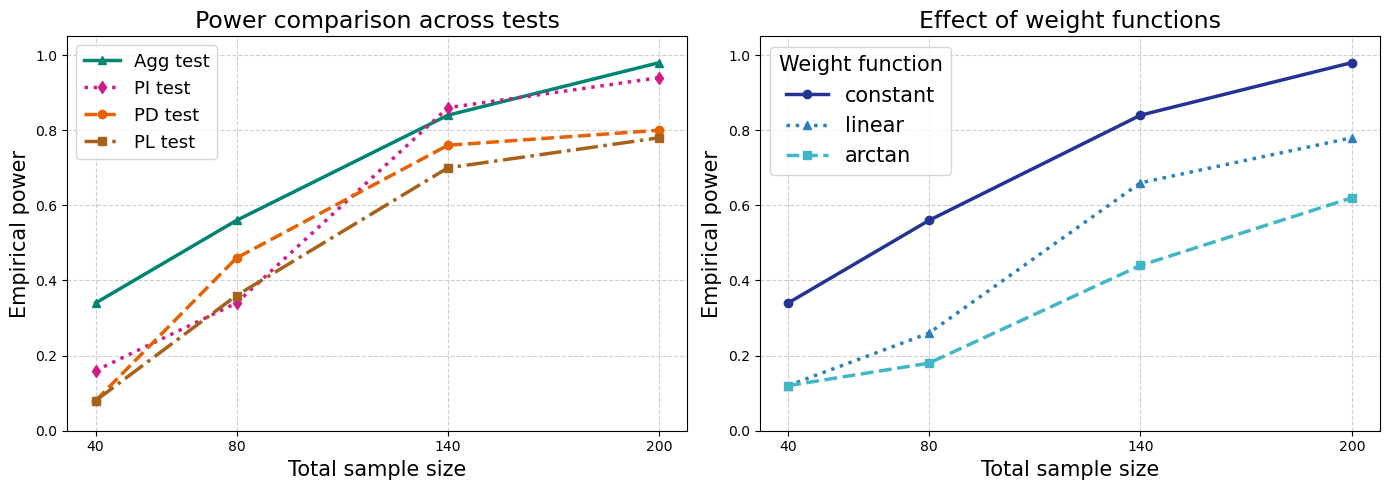

In [13]:
list_npc=np.array([40,80,140,200])
colors=['#018571','#d01c8b','#e66101','#a6611a']
fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 row, 2 columns
colors2=['#253494','#2c7fb8','#41b6c4','#a1dab4']
# --- Left plot: Comparison across tests ---
axes[0].plot(list_npc, Aggtest_result, marker='^', label="Agg test",linestyle='-',color=colors[0], lw=2.5)
axes[0].plot(list_npc, PI_result, marker='d', label="PI test",linestyle=':',color=colors[1], lw=2.5)
axes[0].plot(list_npc, PD_result, marker='o', label="PD test",linestyle='--',color=colors[2], lw=2.5)
axes[0].plot(list_npc, PL_result, marker='s', label="PL test",linestyle='-.',color=colors[3], lw=2.5)
axes[0].set_xlabel("Total sample size",fontsize=15)
axes[0].set_ylabel("Empirical power",fontsize=15)
axes[0].set_title("Power comparison across tests",fontsize=17)
axes[0].set_ylim(0,1.05)
axes[0].set_xticks(list_npc, [str(x) for x in list_npc])
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(fontsize=13)

# --- Right plot: Effect of weight functions ---
list_npc=np.array([40,80,140,200])
axes[1].plot(list_npc, Aggtest_result_const, marker='o', label="constant",linestyle='-',color=colors2[0], lw=2.5)
axes[1].plot(list_npc, Aggtest_result_linear, marker='^', label="linear",linestyle=':',color=colors2[1], lw=2.5)
axes[1].plot(list_npc, Aggtest_result_arctan, marker='s', label="arctan",linestyle='--',color=colors2[2], lw=2.5)
axes[1].set_xlabel("Total sample size",fontsize=15)
axes[1].set_ylabel("Empirical power",fontsize=15)
axes[1].set_title("Effect of weight functions",fontsize=17)
axes[1].set_ylim(0,1.05)
axes[1].set_xticks(list_npc, [str(x) for x in list_npc])
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(fontsize=15,title="Weight function",title_fontsize=15)

plt.tight_layout()
plt.savefig("results/figures/figure_file/Cirlces_Simulation_samplesize.png", dpi=300)
plt.savefig("results/figures/figure_file/Cirlces_Simulation_samplesize.pdf")
plt.show()


In [174]:
list_npc=np.array([40,80,140,200])
latex_code = simulation_to_latex_table(
    list_npc,
    Aggtest_result, PI_result, PD_result, PL_result,
    weight_dictionary={'constant':Aggtest_result_const,
                      'linear':Aggtest_result_linear,
                       'arctan':Aggtest_result_arctan
                        })
print(latex_code)


\begin{table}[H]
\centering
\caption{Test comparison}
\label{tab:test_comp}
\begin{tabular}{lcccc}
\toprule
Method\$\sigma$ & $40$ & $80$ & $140$ & $200$ \\
\midrule
Agg test & 0.340 & 0.560 & 0.840 & 0.980 \\
PI test & 0.160 & 0.340 & 0.860 & 0.940 \\
PD test & 0.080 & 0.460 & 0.760 & 0.800 \\
PL test & 0.080 & 0.360 & 0.700 & 0.780 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}[H]
\centering
\caption{Weight comparison}
\label{tab:weight_comp}
\begin{tabular}{lcccc}
\toprule
Weight & $40$ & $80$ & $140$ & $200$ \\
\midrule
constant & 0.340 & 0.560 & 0.840 & 0.980 \\
linear & 0.120 & 0.260 & 0.660 & 0.780 \\
arctan & 0.120 & 0.180 & 0.440 & 0.620 \\
\bottomrule
\end{tabular}
\end{table}


# Orbit5k Data

In [15]:
file_list = [
    "data/orbit_data/orbit5k_X_original_00.npy",
    "data/orbit_data/orbit5k_X_original_05.npy",
    "data/orbit_data/orbit5k_X_original_10.npy",
    "data/orbit_data/orbit5k_X_original_15.npy",
    "data/orbit_data/orbit5k_X_original_20.npy",
    "data/orbit_data/orbit5k_X_original_25.npy",
    "data/orbit_data/orbit5k_X_original_30.npy",
    "data/orbit_data/orbit5k_X_original_35.npy",
]
arrays = [np.load(f) for f in file_list]
X = np.stack(arrays, axis=0)
y = np.load("data/orbit_data/orbit5k_y.npy")
X_r1 = X[:,np.where(y==0)[0],:,:]
X_r2 = X[:,np.where(y==2)[0],:,:]
X_r3 = X[:,np.where(y==4)[0],:,:]

In [16]:
PD_r1 = loadpkl('data/orbit_data/PD_r1.pkl')
PD_r2 = loadpkl('data/orbit_data/PD_r2.pkl')
PD_r3 = loadpkl('data/orbit_data/PD_r3.pkl')

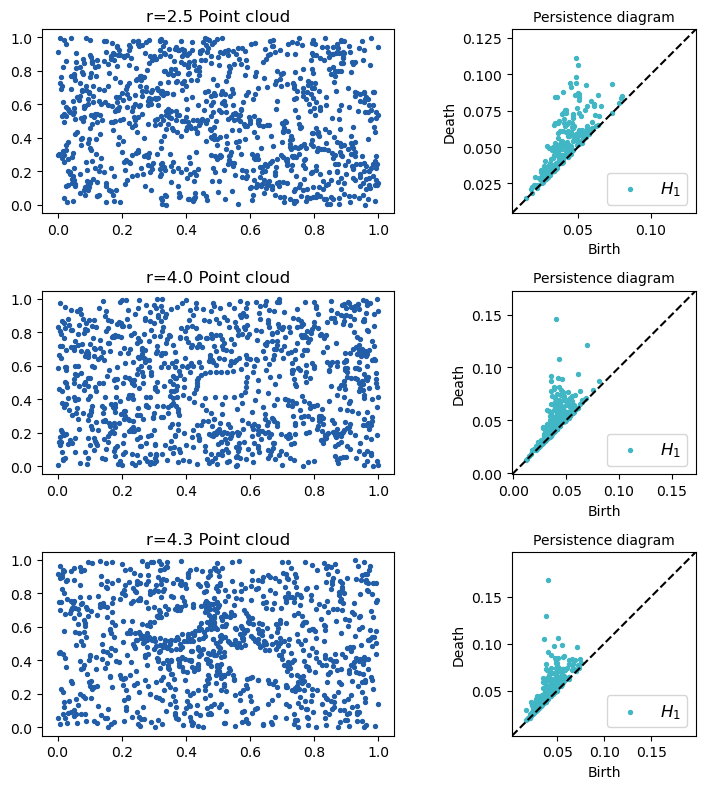

In [18]:
markers = {0: "^", 1: "o"}
colors  = {0:"#225ea8", 1: "#41b6c4"}
fig, axes = plt.subplots(3, 2, figsize=(8, 8))


axes[0,0].scatter(X_r1[0][0][:,0],X_r1[0][0][:,1],s=8,color=colors[0])
axes[0,0].set_title("r=2.5 Point cloud")
deco_pd(ax=axes[0,1],diagrams=[1,PD_r1[0][0]],colors=colors,markers=markers,size=8,plot_only=[1],ticks=True,title='Persistence diagram')


axes[1,0].scatter(X_r2[0][0][:,0],X_r2[0][0][:,1],s=8,color=colors[0])
axes[1,0].set_title("r=4.0 Point cloud")

# plot_diagrams([1,PD_r2[0][0]], plot_only=[1],ax=axes[1,1], title=None, xy_range=None, show=False)
# axes[1,1].set_title("Persistence Diagram")
deco_pd(ax=axes[1,1],diagrams=[1,PD_r2[0][0]],colors=colors,markers=markers,size=8,plot_only=[1],ticks=True,title='Persistence diagram')


axes[2,0].scatter(X_r3[0][0][:,0],X_r3[0][0][:,1],s=8,color=colors[0])
axes[2,0].set_title("r=4.3 Point cloud")

# plot_diagrams([1,PD_r3[0][0]], plot_only=[1],ax=axes[2,1], title=None, xy_range=None, show=False)
# axes[2,1].set_title("Persistence Diagram")
deco_pd(ax=axes[2,1],diagrams=[1,PD_r3[0][0]],colors=colors,markers=markers,size=8,plot_only=[1],ticks=True,title='Persistence diagram')

plt.tight_layout()
plt.savefig("results/figures/figure_file/Orbit.png", dpi=300)
plt.savefig("results/figures/figure_file/Orbit.pdf")
plt.show()

# Musical Instruments

In [21]:
N=60
flute = [pd.read_csv(f"data/flute_diagrams/flute_onedim_{i}.csv").to_numpy() for i in range(1, N+1)]
clarinet = [pd.read_csv(f"data/clarinet_diagrams/clarinet_onedim_{i}.csv").to_numpy() for i in range(1, N+1)]

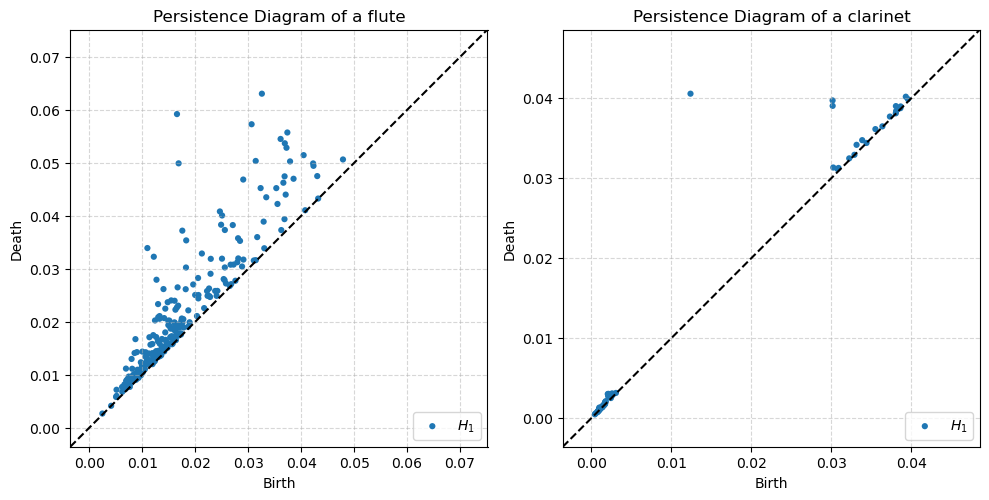

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1행 2열
# PD1
plot_diagrams([1,flute[0]], plot_only=[1],ax=axes[0], title=None, xy_range=None, show=False)
axes[0].set_title("Persistence Diagram of a flute", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.5)

# PD2
plot_diagrams([1,clarinet[0]], plot_only=[1],ax=axes[1], title=None, xy_range=None, show=False)
axes[1].set_title("Persistence Diagram of a clarinet", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("results/figures/figure_file/PDsofsounds.pdf", dpi=300)
plt.show()


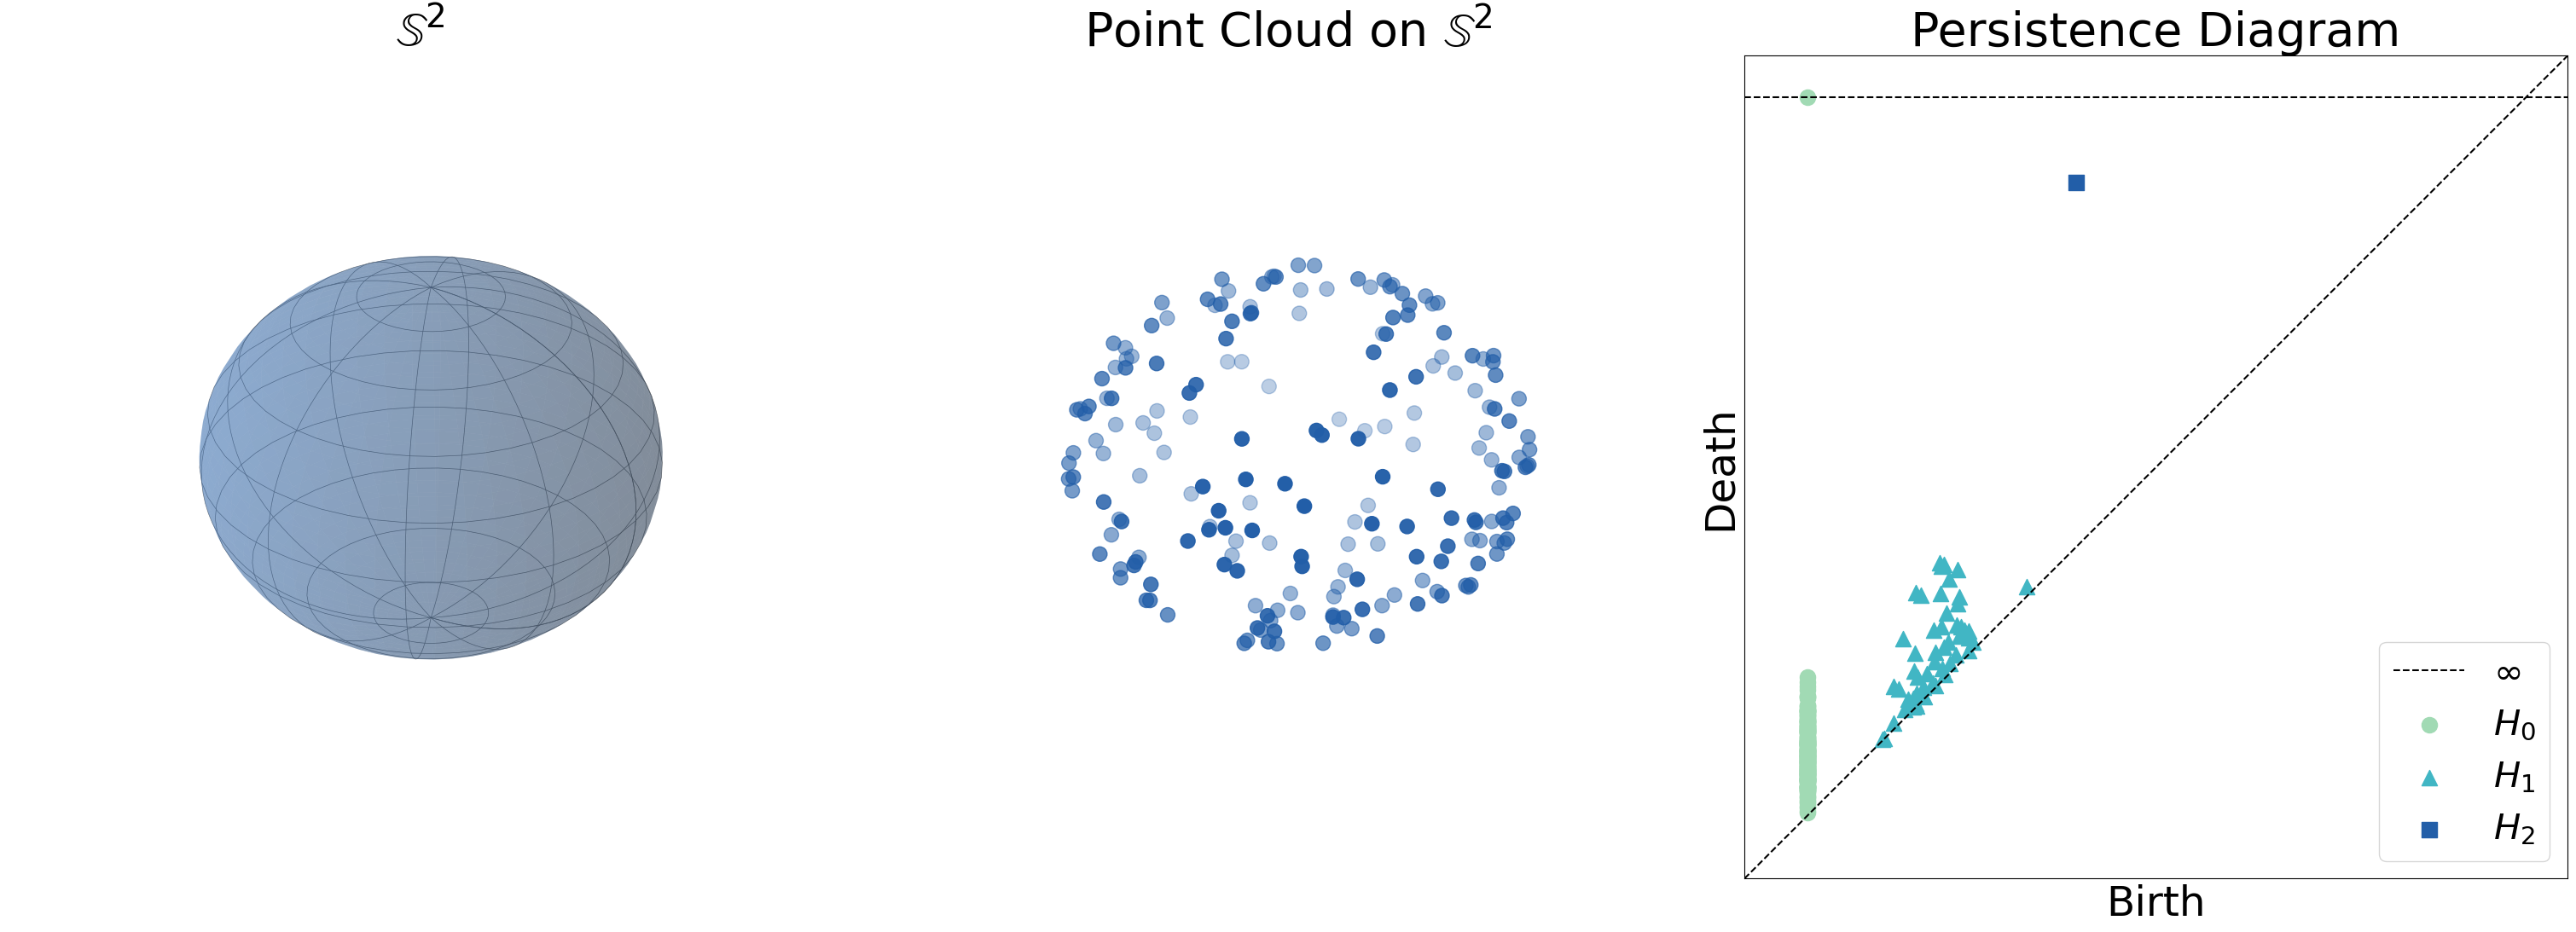

In [23]:
def sample_sphere(n_points):
    phi = np.random.uniform(0, 2*np.pi, n_points)
    cos_theta = np.random.uniform(-1, 1, n_points)
    theta = np.arccos(cos_theta)
    x = np.sin(theta)*np.cos(phi)
    y = np.sin(theta)*np.sin(phi)
    z = np.cos(theta)
    return np.vstack([x, y, z]).T

n_points = 200
X = sample_sphere(n_points)

diagrams = ripser(X, maxdim=2)['dgms']

fig = plt.figure(figsize=(30, 12))

# --- left: S^2 ---
ax1 = fig.add_subplot(1,3,1, projection='3d')
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_s = np.outer(np.cos(u), np.sin(v))
y_s = np.outer(np.sin(u), np.sin(v))
z_s = np.outer(np.ones(np.size(u)), np.cos(v))
ax1.plot_surface(x_s, y_s, z_s, color='#225ea8', alpha=0.3, edgecolor='none')
ax1.plot_wireframe(x_s, y_s, z_s, color='gray', linewidth=0.5, rstride=5, cstride=5)
ax1.set_title(r'$\mathbb{S}^2$', fontsize=40)
ax1.set_xticks(np.arange(-1, 1.1, 0.5))
ax1.set_yticks(np.arange(-1, 1.1, 0.5))
ax1.set_zticks(np.arange(-1, 1.1, 0.5))
ax1.axis('off')

# --- middle: point cloud ---
ax2 = fig.add_subplot(1,3,2, projection='3d')
ax2.scatter(X[:,0], X[:,1], X[:,2], color='#225ea8', s=150)
ax2.set_title(r'Point Cloud on $\mathbb{S}^2$', fontsize=40)
ax2.set_xticks(np.arange(-1, 1.1, 0.5))
ax2.set_yticks(np.arange(-1, 1.1, 0.5))
ax2.set_zticks(np.arange(-1, 1.1, 0.5))
ax2.axis('off')

# --- right: persistence diagram ---
ax3 = fig.add_subplot(1, 3, 3)

# 1) plotting - origninal diagram
plot_diagrams(diagrams, ax=ax3, show=False, size=170)
points = []
for p in ax3.collections:
    arr = p.get_offsets()
    for xy in arr:
        points.append(tuple(xy))

# y_max
x_max, y_max = max(points, key=lambda t: t[1])


for artist in ax3.collections[:]:
    artist.remove()

# -------------------------------
# no points in the diagram 
# but diagonal line 
# -------------------------------

markers = {0: "o", 1: "^", 2: "s"}
colors  = {0: "#a1dab4", 1: "#41b6c4", 2: "#225ea8"}

for i, diag in enumerate(diagrams):
    if len(diag) == 0:
        continue
    births = diag[:, 0]
    deaths = diag[:, 1]

    ax3.scatter(
        births, deaths,
        s=170,
        marker=markers.get(i, "o"),
        color=colors.get(i, "black"),
        label=f"$H_{i}$"
    )
    if i==0:
        ax3.scatter(x_max,y_max,s=170,marker=markers.get(i, "o"),
        color=colors.get(i, "black"))

ax3.set_title("Persistence Diagram", fontsize=40)
ax3.set_xlabel("Birth", fontsize=35)
ax3.set_ylabel("Death", fontsize=35)
ax3.set_xticks([])
ax3.set_yticks([])
ax3.legend(fontsize=30)

plt.tight_layout(pad=0)
plt.savefig('results/figures/figure_file/pdexample.pdf',
            dpi=600, bbox_inches='tight')
plt.show()


## Torus

In [25]:
def Poisson_homo_torus(lam,R,r):
    """
    :param lam: intensity per unit area on torus surface
    :param R: major radius
    :param r: minor radius
    reference: "Sampling from a manifold." by Persi Diaconis and TDA R-package's torusUnif function
    """
    total_intensity = 4*math.pi**2*R*r
    n=np.random.poisson(lam*total_intensity)
    theta =np.array([])
    while len(theta)<n:
        xvec= np.random.uniform(0,2*math.pi,1)
        yvec= np.random.uniform(0,1/math.pi,1)
        fx= (1+ (r/R)*np.cos(xvec))/(2*math.pi)
        if yvec <fx :
            theta=np.append(theta,xvec)
    phi=np.random.uniform(0,2*math.pi,n)
    x = (R+ r*np.cos(theta))*np.cos(phi)
    y = (R+ r*np.cos(theta))*np.sin(phi)
    z = r*np.sin(theta)
    return np.column_stack((x,y,z))

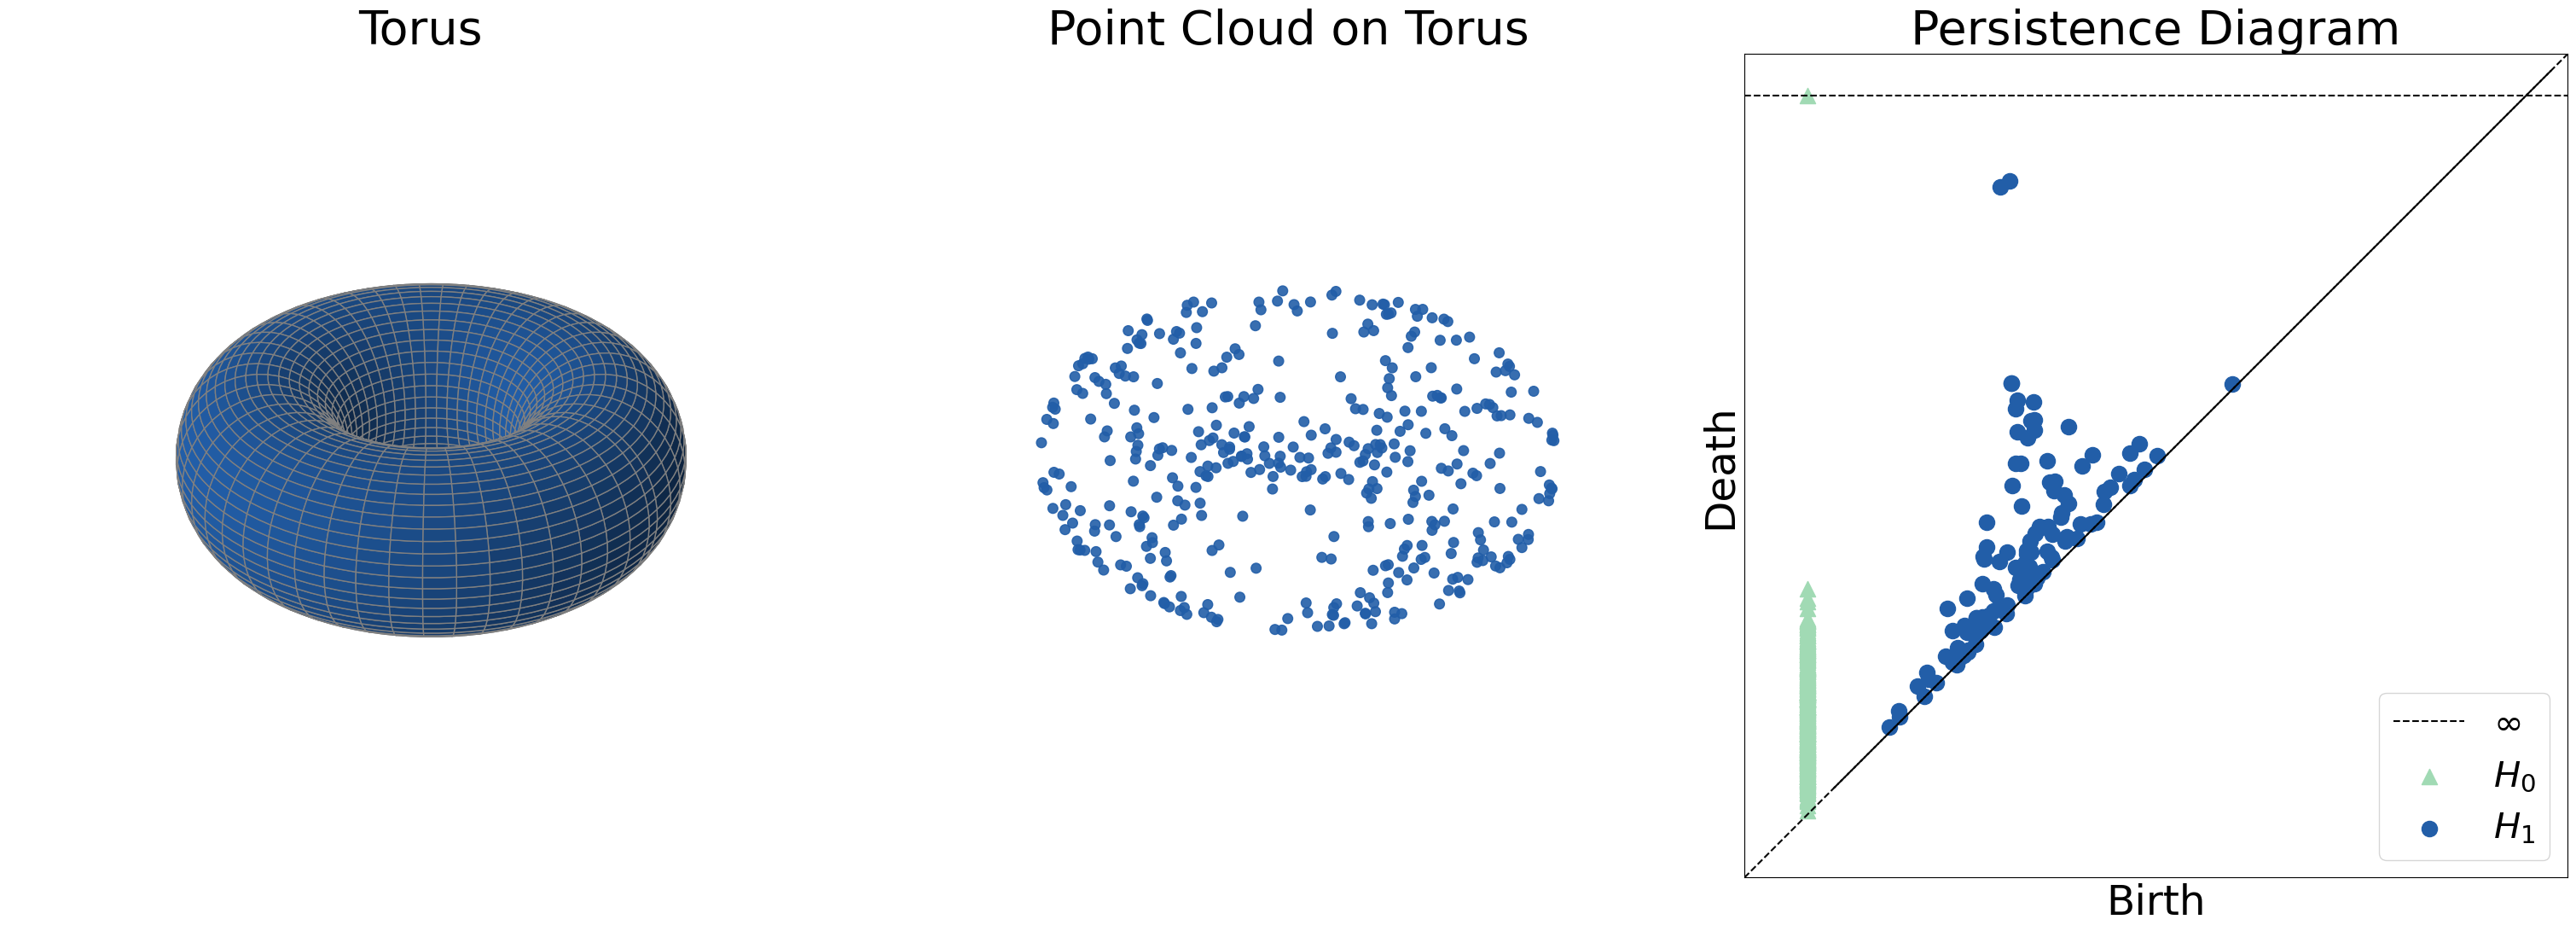

In [26]:
# Parameters for the torus
R = 2  # Major radius
r = 1  # Minor radius

# Create a meshgrid for u (angle around the main circle) and v (angle around the tube)
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, 2 * np.pi, 50)
u, v = np.meshgrid(u, v)

# Parametric equations for the torus
x = (R + r * np.cos(v)) * np.cos(u)
y = (R + r * np.cos(v)) * np.sin(u)
z = r * np.sin(v)

Data =Poisson_homo_torus(5,R,r)
xs, ys, zs = Data[:,0], Data[:,1], Data[:,2]
diagrams = ripser(Data, maxdim=1)['dgms']


fig = plt.figure(figsize=(30, 12))


ax1 = fig.add_subplot(1,3,1, projection='3d')
ax1.plot_surface(x, y, z, color='#225ea8', edgecolor='gray', alpha=1)
#ax1.plot_wireframe(x_s, y_s, z_s, color='gray', linewidth=0.5, rstride=5, cstride=5)
ax1.set_title('Torus', fontsize=40)


# --- middle: point cloud ---
ax2 = fig.add_subplot(1,3,2, projection='3d')
ax2.scatter(xs, ys, zs, color='#225ea8', s=70, alpha=0.9)
ax2.set_title('Point Cloud on Torus', fontsize=40)
ax2.set_xticks(np.arange(-1, 1.1, 0.5))
ax2.set_yticks(np.arange(-1, 1.1, 0.5))
ax2.set_zticks(np.arange(-1, 1.1, 0.5))

# --- right: persistence diagram ---
ax3 = fig.add_subplot(1,3,3)
plot_diagrams(diagrams,  plot_only=[1],ax=ax3, show=False, size=200)
# 1) plotting - origninal diagram
plot_diagrams(diagrams, ax=ax3, show=False, size=170)
points = []
for p in ax3.collections:
    arr = p.get_offsets()
    for xy in arr:
        points.append(tuple(xy))

# y_max
x_max, y_max = max(points, key=lambda t: t[1])



# 2) removing each points from the original diagram

for artist in ax3.collections[:]:
    artist.remove()

# -------------------------------
# no points in the diagram 
# but diagonal line 
# -------------------------------

markers = {0: "^", 1: "o"}
colors  = {0: "#a1dab4", 1: "#225ea8"}

for i, diag in enumerate(diagrams):
    if len(diag) == 0:
        continue
    births = diag[:, 0]
    deaths = diag[:, 1]

    ax3.scatter(
        births, deaths,
        s=170,
        marker=markers.get(i, "o"),
        color=colors.get(i, "black"),
        label=f"$H_{i}$"
    )
    if i==0:
        ax3.scatter(x_max,y_max,s=170,marker=markers.get(i, "o"),
        color=colors.get(i, "black"))


ax3.set_title('Persistence Diagram', fontsize=40)
ax3.set_xlabel('Birth', fontsize=35)
ax3.set_ylabel('Death', fontsize=35)
legend = ax3.legend(fontsize=30)
ax3.set_xticks([])
ax3.set_yticks([])
# Set aspect and remove axes
ax1.set_box_aspect([1+R/r, 1+R/r, 1])
ax1.axis('off')
ax2.set_box_aspect([1+R/r, 1+R/r, 1])    
ax2.axis('off')

plt.tight_layout(pad=0)
plt.savefig('results/figures/figure_file/Torus_example.pdf',
             dpi=600, bbox_inches='tight')
plt.show()


In [27]:
np.random.seed(42)
R = 2  # Major radius
r = 1  # Minor radius
diagram_list=[]
N=3
for _ in range(N):
    Data =Poisson_homo_torus(5,R,r)
    diagram_list.append(ripser(Data, maxdim=1)['dgms'][1])

/var/folders/l8/x4_rg_g96h3bqtgtpq_bycvh0000gn/T/ipykernel_1462/1984191445.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


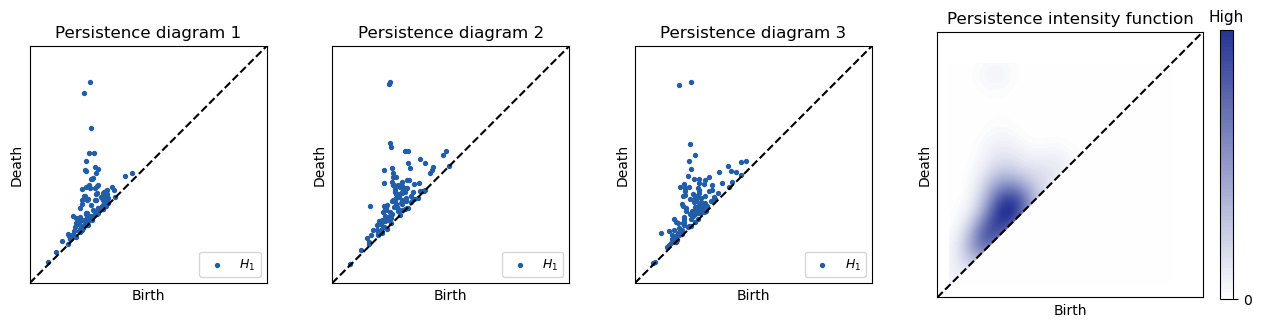

In [30]:
plot_persistence_intensity(diagram_list,filename='Intensity_function_example',title='Persistence intensity function',title_size=12,bandwidth=0.1) 

## Torus-Empirical power

### Varying noise

In [32]:
PD_result = loadpkl('results/simulation_results/Torus_results/Torus_PD_result.pkl')[0:-1]
PL_result = loadpkl('results/simulation_results/Torus_results/Torus_PL_result.pkl')[0:-1]
Aggtest_result = loadpkl('results/simulation_results/Torus_results/Torus_Agg_root_opt.pkl')[0:-1]
result = pyreadr.read_r("results/simulation_results/Torus_results/Torus_PI_power_result.rds")
PI_result = np.array(result[None]).reshape(-1)[0:-1] # pandas Series/DataFrame 

Aggtest_result_root= loadpkl('results/simulation_results/Torus_results/Torus_Agg_root_opt.pkl')[0:-1]
Aggtest_result_linear = loadpkl('results/simulation_results/Torus_results/Torus_Agg_linear_opt.pkl')[0:-1]
Aggtest_result_third = loadpkl('results/simulation_results/Torus_results/Torus_Agg_third_opt.pkl')[0:-1]
Aggtest_result_oneoverfour = loadpkl('results/simulation_results/Torus_results/Torus_Agg_oneoverfour_opt.pkl')[0:-1]
Aggtest_result_constant = loadpkl('results/simulation_results/Torus_results/Torus_Agg_constant_opt.pkl')[0:-1]

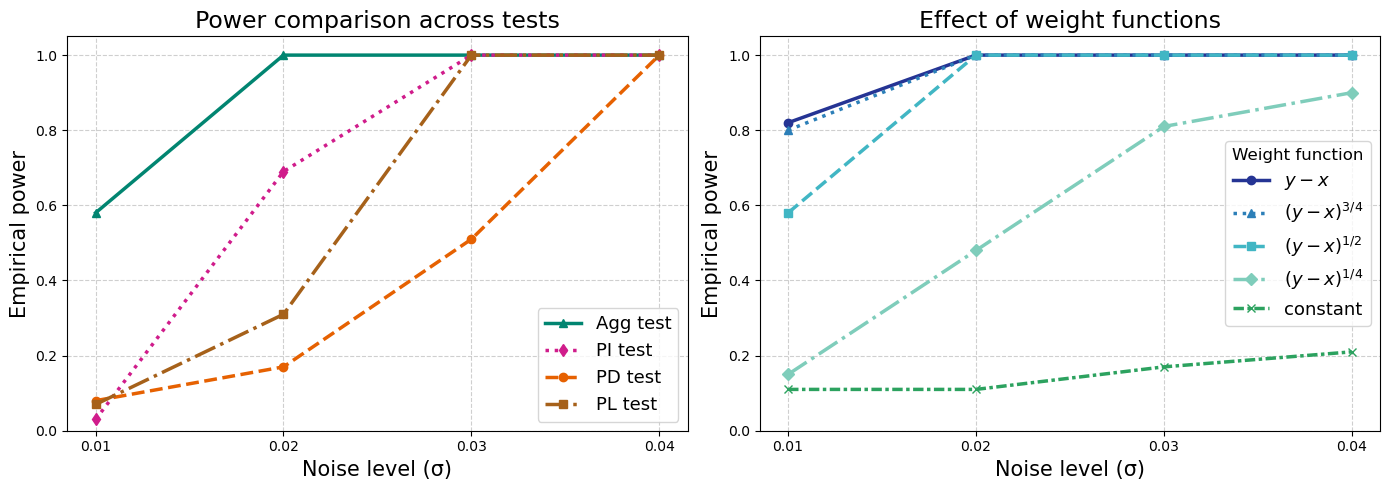

In [33]:
noise_levels =  np.array([0.01,0.02,0.03,0.04,0.05])
colors=['#018571','#d01c8b','#e66101','#a6611a']
fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 row, 2 columns
colors2 = ['#253494','#2c7fb8','#41b6c4','#7fcdbb','#2ca25f']
# --- Left plot: Comparison across tests ---
axes[0].plot(noise_levels[0:-1], Aggtest_result, marker='^', label="Agg test",linestyle='-',color=colors[0], lw=2.5)
axes[0].plot(noise_levels[0:-1], PI_result, marker='d', label="PI test",linestyle=':',color=colors[1], lw=2.5)
axes[0].plot(noise_levels[0:-1], PD_result, marker='o', label="PD test",linestyle='--',color=colors[2], lw=2.5)
axes[0].plot(noise_levels[0:-1], PL_result, marker='s', label="PL test",linestyle='-.',color=colors[3], lw=2.5)
axes[0].set_xlabel("Noise level (σ)",fontsize=15)
axes[0].set_ylabel("Empirical power",fontsize=15)
axes[0].set_title("Power comparison across tests",fontsize=17)
axes[0].set_ylim(0,1.05)
axes[0].set_xticks(noise_levels[0:-1], [str(x) for x in noise_levels[0:-1]])
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(fontsize=13)

# --- Right plot: Effect of weight functions ---
axes[1].plot(noise_levels[0:-1], Aggtest_result_linear,
             marker='o', linestyle='-', label=r"$y-x$", color=colors2[0], lw=2.5)

axes[1].plot(noise_levels[0:-1], Aggtest_result_third,
             marker='^', linestyle=':', label=r"$(y-x)^{3/4}$", color=colors2[1], lw=2.5)

axes[1].plot(noise_levels[0:-1], Aggtest_result_root,
             marker='s', linestyle='--', label=r"$(y-x)^{1/2}$", color=colors2[2], lw=2.5)

axes[1].plot(noise_levels[0:-1], Aggtest_result_oneoverfour,
             marker='D', linestyle='-.', label=r"$(y-x)^{1/4}$", color=colors2[3], lw=2.5)

axes[1].plot(noise_levels[0:-1], Aggtest_result_constant,
             marker='x', linestyle=(0, (3, 1, 1, 1)), label=r"constant", color=colors2[4], lw=2.5)
axes[1].set_xlabel("Noise level (σ)",fontsize=15)
axes[1].set_ylabel("Empirical power",fontsize=15)
axes[1].set_title("Effect of weight functions",fontsize=17)
axes[1].set_ylim(0,1.05)
axes[1].set_xticks(noise_levels[0:-1], [str(x) for x in noise_levels[0:-1]])
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(fontsize=13,title=r"Weight function",title_fontsize=12)

plt.tight_layout()
plt.savefig("results/figures/figure_file/Torus_Simulation.png", dpi=300)
plt.savefig("results/figures/figure_file/Torus_Simulation.pdf")
plt.show()


In [181]:
latex_code = simulation_to_latex_table(
    noise_levels[:-1],
    Aggtest_result, PI_result, PD_result, PL_result,
    weight_dictionary={'$y-x$':Aggtest_result_linear,
                      '$(y-x)^{\frac{3}{4}}$':Aggtest_result_third,
                       '$(y-x)^{\frac{1}{2}}$':Aggtest_result_root,
                       '$(y-x)^{\frac{1}{4}}$':Aggtest_result_oneoverfour,
                       'constant':Aggtest_result_constant
                        }
)

print(latex_code)


\begin{table}[H]
\centering
\caption{Test comparison}
\label{tab:test_comp}
\begin{tabular}{lcccc}
\toprule
Method\$\sigma$ & $0.01$ & $0.02$ & $0.03$ & $0.04$ \\
\midrule
Agg test & 0.580 & 1.000 & 1.000 & 1.000 \\
PI test & 0.030 & 0.690 & 1.000 & 1.000 \\
PD test & 0.080 & 0.170 & 0.510 & 1.000 \\
PL test & 0.070 & 0.310 & 1.000 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}[H]
\centering
\caption{Weight comparison}
\label{tab:weight_comp}
\begin{tabular}{lcccc}
\toprule
Weight\$\sigma$ & $0.01$ & $0.02$ & $0.03$ & $0.04$ \\
\midrule
$y-x$ & 0.820 & 1.000 & 1.000 & 1.000 \\
$(y-x)^{rac{3}{4}}$ & 0.800 & 1.000 & 1.000 & 1.000 \\
$(y-x)^{rac{1}{2}}$ & 0.580 & 1.000 & 1.000 & 1.000 \\
$(y-x)^{rac{1}{4}}$ & 0.150 & 0.480 & 0.810 & 0.900 \\
constant & 0.110 & 0.110 & 0.170 & 0.210 \\
\bottomrule
\end{tabular}
\end{table}


In [164]:
Aggtest_result_oneoverfour

array([0.15, 0.48, 0.81, 0.9 ])

### Varying sample-size

In [34]:
PD_result = loadpkl('results/simulation_results/Torus_results/Torus_PD_result_diffsamples.pkl')
PL_result = loadpkl('results/simulation_results/Torus_results/Torus_PL_result_diffsamples.pkl')
Aggtest_result = loadpkl('results/simulation_results/Torus_results/Torus_Agg_root_opt_diffsamples.pkl')
result = pyreadr.read_r("results/simulation_results/Torus_results/Torus_PI_power_result_diffsamples.rds")
PI_result = np.array(result[None]).reshape(-1) # pandas Series/DataFrame 

Aggtest_result_root= loadpkl('results/simulation_results/Torus_results/Torus_Agg_root_opt_diffsamples.pkl')
Aggtest_result_linear = loadpkl('results/simulation_results/Torus_results/Torus_Agg_linear_opt_diffsamples.pkl')
Aggtest_result_third = loadpkl('results/simulation_results/Torus_results/Torus_Agg_third_opt_diffsamples.pkl')
Aggtest_result_oneoverfour = loadpkl('results/simulation_results/Torus_results/Torus_Agg_oneoverfour_opt_diffsamples.pkl')
Aggtest_result_constant = loadpkl('results/simulation_results/Torus_results/Torus_Agg_constant_opt_diffsamples.pkl')

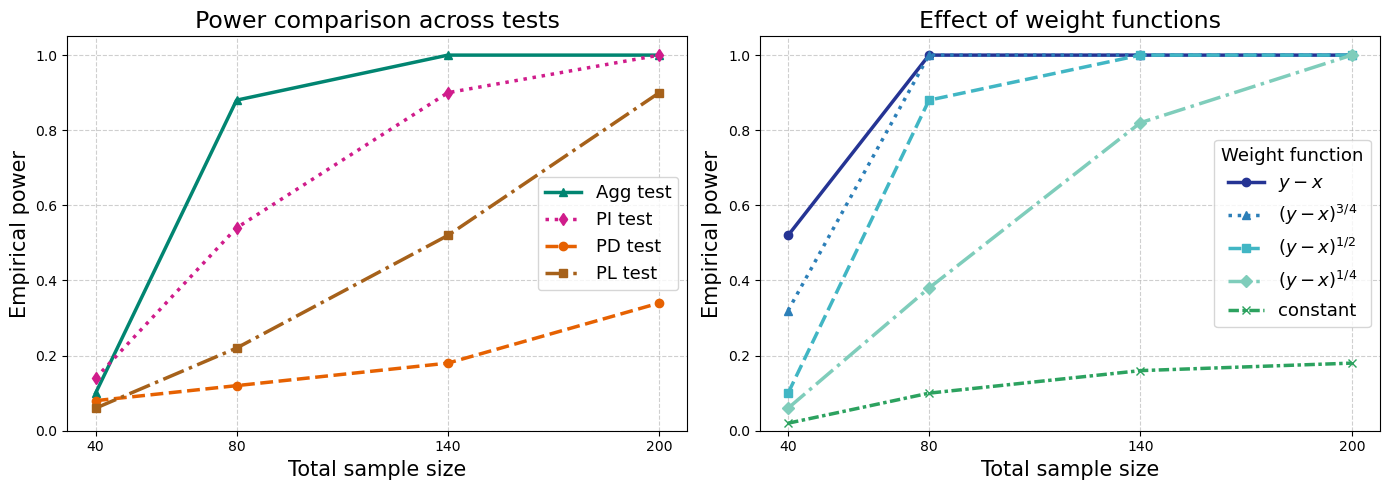

In [35]:
list_npc=np.array([40,80,140,200])
colors=['#018571','#d01c8b','#e66101','#a6611a']
fig, axes = plt.subplots(1, 2, figsize=(14,5))  # 1 row, 2 columns
colors2 = ['#253494','#2c7fb8','#41b6c4','#7fcdbb','#2ca25f']
# --- Left plot: Comparison across tests ---
axes[0].plot(list_npc, Aggtest_result, marker='^', label="Agg test",linestyle='-',color=colors[0], lw=2.5)
axes[0].plot(list_npc, PI_result, marker='d', label="PI test",linestyle=':',color=colors[1], lw=2.5)
axes[0].plot(list_npc, PD_result, marker='o', label="PD test",linestyle='--',color=colors[2], lw=2.5)
axes[0].plot(list_npc, PL_result, marker='s', label="PL test",linestyle='-.',color=colors[3], lw=2.5)
axes[0].set_xlabel("Total sample size",fontsize=15)
axes[0].set_ylabel("Empirical power",fontsize=15)
axes[0].set_title("Power comparison across tests",fontsize=17)
axes[0].set_ylim(0,1.05)
axes[0].set_xticks(list_npc, [str(x) for x in list_npc])
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(fontsize=13)

# --- Right plot: Effect of weight functions ---

axes[1].plot(list_npc, Aggtest_result_linear, marker='o', label=r"$y-x$",linestyle='-',color=colors2[0], lw=2.5)
axes[1].plot(list_npc, Aggtest_result_third, marker='^', label=r"$(y-x)^{3/4}$",linestyle=':',color=colors2[1], lw=2.5)
axes[1].plot(list_npc, Aggtest_result_root, marker='s', label=r"$(y-x)^{1/2}$",linestyle='--',color=colors2[2], lw=2.5)
axes[1].plot(list_npc, Aggtest_result_oneoverfour,
             marker='D', linestyle='-.', label=r"$(y-x)^{1/4}$", color=colors2[3], lw=2.5)
axes[1].plot(list_npc, Aggtest_result_constant,
             marker='x', linestyle=(0, (3, 1, 1, 1)), label="constant", color=colors2[4], lw=2.5)
axes[1].set_xlabel("Total sample size",fontsize=15)
axes[1].set_ylabel("Empirical power",fontsize=15)
axes[1].set_title("Effect of weight functions",fontsize=17)
axes[1].set_ylim(0,1.05)
axes[1].set_xticks(list_npc, [str(x) for x in list_npc])
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(fontsize=13,title=r"Weight function",title_fontsize=13)

plt.tight_layout()
plt.savefig("results/figures/figure_file/Torus_Simulation_samplesize.png", dpi=300)
plt.savefig("results/figures/figure_file/Torus_Simulation_samplesize.pdf")
plt.show()


In [183]:
list_npc=np.array([40,80,140,200])
latex_code = simulation_to_latex_table(
    list_npc,
    Aggtest_result, PI_result, PD_result, PL_result,
    weight_dictionary={'$y-x$':Aggtest_result_linear,
                      '$(y-x)^{\frac{3}{4}}$':Aggtest_result_third,
                       '$(y-x)^{\frac{1}{2}}$':Aggtest_result_root,
                       '$(y-x)^{\frac{1}{4}}$':Aggtest_result_oneoverfour,
                       'constant':Aggtest_result_constant
                        }
)

print(latex_code)


\begin{table}[H]
\centering
\caption{Test comparison}
\label{tab:test_comp}
\begin{tabular}{lcccc}
\toprule
Method\$\sigma$ & $40$ & $80$ & $140$ & $200$ \\
\midrule
Agg test & 0.100 & 0.880 & 1.000 & 1.000 \\
PI test & 0.140 & 0.540 & 0.900 & 1.000 \\
PD test & 0.080 & 0.120 & 0.180 & 0.340 \\
PL test & 0.060 & 0.220 & 0.520 & 0.900 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}[H]
\centering
\caption{Weight comparison}
\label{tab:weight_comp}
\begin{tabular}{lcccc}
\toprule
Weight\$\sigma$ & $40$ & $80$ & $140$ & $200$ \\
\midrule
$y-x$ & 0.520 & 1.000 & 1.000 & 1.000 \\
$(y-x)^{rac{3}{4}}$ & 0.320 & 1.000 & 1.000 & 1.000 \\
(y-x)^{rac{1}{2}} & 0.100 & 0.880 & 1.000 & 1.000 \\
(y-x)^{rac{1}{4}} & 0.060 & 0.380 & 0.820 & 1.000 \\
constant & 0.020 & 0.100 & 0.160 & 0.180 \\
\bottomrule
\end{tabular}
\end{table}


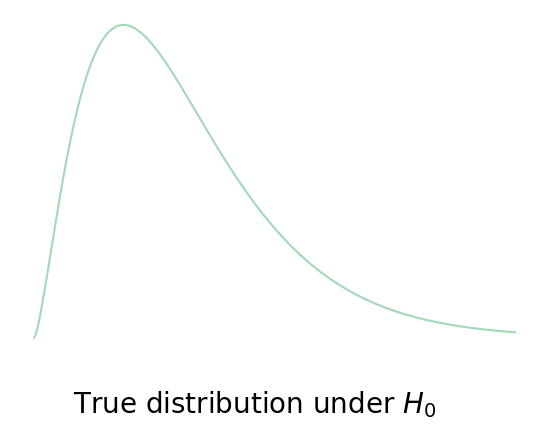

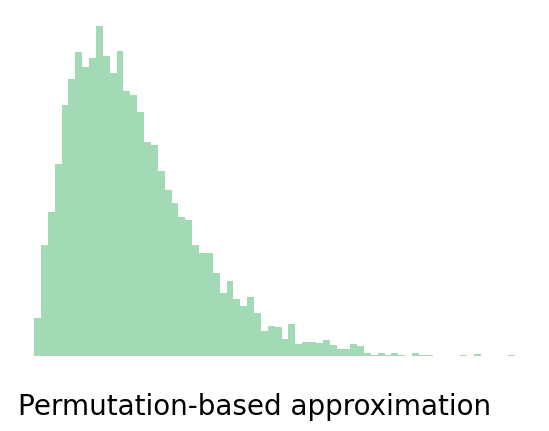

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2

# -----------------------------
# Parameters
# -----------------------------
np.random.seed(0)
df = 5
n = 60
B = 5000
alpha = 0.05

# -----------------------------
# Data under H0
# -----------------------------
X = np.random.normal(0, 1, (n, df))

# -----------------------------
# Test statistic
# -----------------------------
mean_vec = X.mean(axis=0)
obs_stat = n * np.sum(mean_vec**2)

# -----------------------------
# Permutation (sign-flip) distribution
# -----------------------------
perm_stats = np.empty(B)
for b in range(B):
    signs = np.random.choice([-1, 1], size=(n, 1))
    X_perm = signs * X
    mean_perm = X_perm.mean(axis=0)
    perm_stats[b] = n * np.sum(mean_perm**2)

colors = {0: "#a1dab4", 1: "#225ea8"}

# =====================================================
# Figure 1: True chi-square distribution
# =====================================================
x = np.linspace(0, np.percentile(perm_stats, 99.5), 500)
q_theory = chi2.ppf(1 - alpha, df)

plt.figure(figsize=(6, 4))
plt.plot(x, chi2.pdf(x, df), color=colors[0])
plt.figtext(0.5, -0.05, r"True distribution under $H_0$", 
            ha="center", fontsize=20)


plt.tight_layout()
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_frame_on(False)

plt.savefig(
    "results/figures/figure_file/True_density_example.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    transparent=True
)
plt.show()

# =====================================================
# Figure 2: Permutation approximation
# =====================================================

plt.figure(figsize=(6, 4))
plt.hist(perm_stats, bins=70, density=True, color=colors[0])
plt.figtext(0.5, -0.05, r"Permutation-based approximation", 
            ha="center", fontsize=20)

plt.tight_layout()
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.gca().set_frame_on(False)

plt.savefig(
    "results/figures/figure_file/Permutation_Approximation.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    transparent=True
)
plt.show()


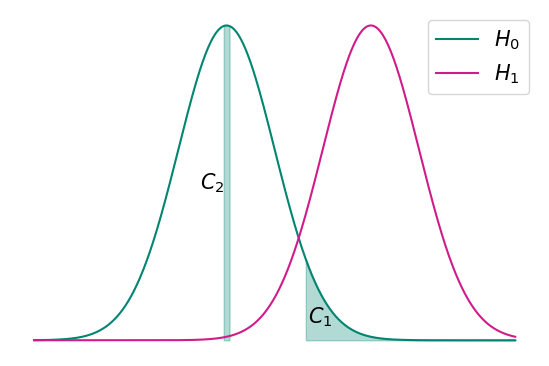

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
colors=['#018571','#d01c8b','#e66101','#a6611a']
# -----------------------------
# Distributions
# -----------------------------
x = np.linspace(-4, 6, 2000)

H0 = norm.pdf(x, 0, 1)
H1 = norm.pdf(x, 3, 1)

# -----------------------------
# Critical regions
# -----------------------------
alpha = 0.05

# C1: right 5% tail under H0
q1 = norm.ppf(1 - alpha)

# C2: central 5% probability mass under H0, symmetric about 0
c = norm.ppf((1 + alpha) / 2)  # P(|Z| <= c) = alpha

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 4))

plt.plot(x, H0, label=r"$H_0$",color=colors[0])
plt.plot(x, H1, label=r"$H_1$",color=colors[1])

# ----- Shade C1 (right tail) -----
x_c1 = x[x >= q1]
plt.fill_between(x_c1, norm.pdf(x_c1, 0, 1), alpha=0.3,color=colors[0])

# C1 label centered in shaded region
c1_center = q1 + 0.3
plt.text(
    c1_center,
    norm.pdf(c1_center, 0, 1) / 2,
    r"$C_1$",
    fontsize=15,
    ha="center",
    va="center",
)

# ----- Shade C2 (central interval) -----
x_c2 = x[(x >= -c) & (x <= c)]
plt.fill_between(x_c2, norm.pdf(x_c2, 0, 1), alpha=0.3,color=colors[0])

# C2 label at the center (x=0)
plt.text(
    0.0-0.3,
    norm.pdf(0.0, 0, 1) / 2,
    r"$C_2$",
    fontsize=15,
    ha="center",
    va="center",
)

plt.legend(fontsize=15)
plt.tight_layout()
plt.axis("off")
plt.savefig(
    "results/figures/figure_file/Critical_region_C1_righttail_C2_central5.pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    transparent=True,
)
plt.show()